In [1]:
import numpy as np
print(np.__version__)

1.26.4


In [1]:
import scipy
import pandas as pd
import nltk
import textstat
from textblob import TextBlob
print("SciPy:", scipy.__version__)
print("pandas:", pd.__version__)
print("All imports OK")

SciPy: 1.16.3
pandas: 2.3.3
All imports OK


In [3]:
pip install textstat 

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 7.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [textstat]━━━ 1/2 [textstat]
Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install textblob

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 625.0/625.0 kB 2.8 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install joblib

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install streamlit

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import re, string
import nltk
import textstat
from textblob import TextBlob
from nltk import pos_tag, word_tokenize
from nltk.corpus import stopwords

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

print("All imports successful.")
print("NumPy:", np.__version__)

All imports successful.
NumPy: 1.26.4


In [1]:
import pandas as pd
import numpy as np
import re
import string
from collections import Counter
import nltk

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

# Column names for LIAR TSV files
liar_columns = [
    'id', 'label', 'statement', 'subject', 'speaker', 'job_title',
    'state', 'party', 'count_barely_true', 'count_false',
    'count_half_true', 'count_mostly_true', 'count_pants_fire', 'context'
]

train_df = pd.read_csv('train.tsv', sep='\t', header=None, names=liar_columns)
valid_df = pd.read_csv('valid.tsv', sep='\t', header=None, names=liar_columns)
test_df  = pd.read_csv('test.tsv',  sep='\t', header=None, names=liar_columns)

# Concatenate — we'll do our own split later
df = pd.concat([train_df, valid_df, test_df], ignore_index=True)

print("Total rows:", len(df))
print("Label distribution:\n", df['label'].value_counts())
print(df.head())
print("Columns:", df.columns.tolist())
print(df.head())

Total rows: 12791
Label distribution:
 label
half-true      2627
false          2507
mostly-true    2454
barely-true    2103
true           2053
pants-fire     1047
Name: count, dtype: int64
           id        label                                          statement  \
0   2635.json        false  Says the Annies List political group supports ...   
1  10540.json    half-true  When did the decline of coal start? It started...   
2    324.json  mostly-true  Hillary Clinton agrees with John McCain "by vo...   
3   1123.json        false  Health care reform legislation is likely to ma...   
4   9028.json    half-true  The economic turnaround started at the end of ...   

                              subject         speaker             job_title  \
0                            abortion    dwayne-bohac  State representative   
1  energy,history,job-accomplishments  scott-surovell        State delegate   
2                      foreign-policy    barack-obama             President   
3     

In [2]:
fake_labels = {'pants-fire', 'false', 'barely-true'}
df['label_binary'] = df['label'].apply(lambda x: 1 if x in fake_labels else 0)

print("Binary label distribution:")
print(df['label_binary'].value_counts())

Binary label distribution:
label_binary
0    7134
1    5657
Name: count, dtype: int64


In [3]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_statement'] = df['statement'].apply(clean_text)
df['full_text'] = df['clean_statement']  # LIAR has no separate title

print(df[['statement', 'clean_statement']].head(3))

                                           statement  \
0  Says the Annies List political group supports ...   
1  When did the decline of coal start? It started...   
2  Hillary Clinton agrees with John McCain "by vo...   

                                     clean_statement  
0  says the annies list political group supports ...  
1  when did the decline of coal start it started ...  
2  hillary clinton agrees with john mccain by vot...  


In [4]:
import textstat
from textblob import TextBlob
from nltk import pos_tag, word_tokenize
from collections import Counter
import re, string
import numpy as np
import pandas as pd
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

# ---------- Style + POS features (same as before) ----------
def get_pos_distribution(text):
    default = {
        'pos_noun_ratio': 0, 'pos_verb_ratio': 0, 'pos_adj_ratio': 0,
        'pos_adv_ratio': 0, 'pos_pron_ratio': 0, 'pos_propn_ratio': 0,
        'pos_num_ratio': 0, 'pos_other_ratio': 0
    }
    if not text or len(text.split()) < 3:
        return default, []
    try:
        tokens = word_tokenize(text)
        tags = pos_tag(tokens)
    except Exception:
        return default, []
    total = len(tags) if tags else 1
    counts = Counter(tag for _, tag in tags)
    def ratio(prefixes):
        return sum(v for k, v in counts.items() if any(k.startswith(p) for p in prefixes)) / total
    dist = {
        'pos_noun_ratio':  ratio(['NN']),
        'pos_verb_ratio':  ratio(['VB']),
        'pos_adj_ratio':   ratio(['JJ']),
        'pos_adv_ratio':   ratio(['RB']),
        'pos_pron_ratio':  ratio(['PRP']),
        'pos_propn_ratio': ratio(['NNP']),
        'pos_num_ratio':   ratio(['CD']),
    }
    dist['pos_other_ratio'] = max(0.0, 1 - sum(dist.values()))
    return dist, tags


def extract_linguistic_features(text):
    if not text or len(text.split()) < 3:
        base = {
            'exclamation_count': 0, 'question_count': 0,
            'all_caps_ratio': 0, 'punctuation_ratio': 0,
            'readability_flesch': 0, 'sentiment_polarity': 0,
            'sentiment_subjectivity': 0, 'avg_word_length': 0,
            'unique_word_ratio': 0, 'stopword_ratio': 0
        }
        pos_dist, _ = get_pos_distribution(text)
        base.update(pos_dist)
        return base

    words = text.split()
    total_chars = len(text)
    exclamation = text.count('!')
    question    = text.count('?')
    caps_words  = sum(1 for w in words if w.isupper() and len(w) > 2)
    all_caps_ratio = caps_words / max(len(words), 1)
    punct_chars = sum(1 for c in text if c in string.punctuation)
    punct_ratio = punct_chars / max(total_chars, 1)
    try:
        flesch = textstat.flesch_reading_ease(text)
    except Exception:
        flesch = 0
    blob = TextBlob(text)
    polarity     = blob.sentiment.polarity
    subjectivity = blob.sentiment.subjectivity
    avg_word_len = np.mean([len(w) for w in words]) if words else 0
    unique_ratio = len(set(words)) / max(len(words), 1)
    stop_ratio   = sum(1 for w in words if w in stop_words) / max(len(words), 1)

    features = {
        'exclamation_count': exclamation,
        'question_count': question,
        'all_caps_ratio': all_caps_ratio,
        'punctuation_ratio': punct_ratio,
        'readability_flesch': flesch,
        'sentiment_polarity': polarity,
        'sentiment_subjectivity': subjectivity,
        'avg_word_length': avg_word_len,
        'unique_word_ratio': unique_ratio,
        'stopword_ratio': stop_ratio
    }
    pos_dist, _ = get_pos_distribution(text)
    features.update(pos_dist)
    return features


# Apply style features
feature_df = df['statement'].apply(lambda x: pd.Series(extract_linguistic_features(str(x))))
df = pd.concat([df, feature_df], axis=1)


# ---------- Speaker history features ----------
credit_cols = [
    'count_barely_true', 'count_false', 'count_half_true',
    'count_mostly_true', 'count_pants_fire'
]
df[credit_cols] = df[credit_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

df['total_ratings'] = df[credit_cols].sum(axis=1).replace(0, 1)
df['truth_ratio'] = (
    df['count_mostly_true'] + df['count_half_true'] + df['count_barely_true']
) / df['total_ratings']
df['fake_ratio'] = (
    df['count_false'] + df['count_pants_fire']
) / df['total_ratings']
df['speaker_reliability'] = df['truth_ratio'] - df['fake_ratio']


# ---------- Categorical metadata ----------
df['party']            = df['party'].fillna('unknown').str.lower().str.strip()
df['job_title']        = df['job_title'].fillna('unknown').str.lower().str.strip()
df['subject_primary']  = df['subject'].fillna('unknown').str.split(',').str[0].str.lower().str.strip()


# ---------- Context features ----------
ctx = df['context'].fillna('').str.lower()
df['is_debate']       = ctx.str.contains('debate').astype(int)
df['is_rally']        = ctx.str.contains('rally').astype(int)
df['is_interview']    = ctx.str.contains('interview').astype(int)
df['is_ad']           = ctx.str.contains('ad|advertisement|commercial').astype(int)
df['is_tweet']        = ctx.str.contains('tweet|twitter').astype(int)
df['is_news_release'] = ctx.str.contains('news release|press').astype(int)
df['is_speech']       = ctx.str.contains('speech|address').astype(int)

print("Feature engineering complete.")
print("Total features:", df.shape[1])

Feature engineering complete.
Total features: 47


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import joblib

# ---------- Column groups ----------
text_col = 'full_text'

# Original style / punctuation features
style_cols = [
    'exclamation_count', 'question_count', 'all_caps_ratio',
    'punctuation_ratio', 'readability_flesch', 'sentiment_polarity',
    'sentiment_subjectivity', 'avg_word_length', 'unique_word_ratio',
    'stopword_ratio'
]

# Original POS features
pos_cols = [
    'pos_noun_ratio', 'pos_verb_ratio', 'pos_adj_ratio', 'pos_adv_ratio',
    'pos_pron_ratio', 'pos_propn_ratio', 'pos_num_ratio', 'pos_other_ratio'
]

# New: speaker credit history features (from Step 5)
history_cols = [
    'count_barely_true', 'count_false', 'count_half_true',
    'count_mostly_true', 'count_pants_fire',
    'truth_ratio', 'fake_ratio', 'speaker_reliability'
]

# New: context features (from Step 5)
context_cols = [
    'is_debate', 'is_rally', 'is_interview', 'is_ad',
    'is_tweet', 'is_news_release', 'is_speech'
]

# New: categorical metadata (from Step 5)
cat_cols = ['party', 'job_title', 'subject_primary']

# Everything the model consumes
feature_cols = (
    [text_col] + style_cols + pos_cols
    + history_cols + context_cols + cat_cols
)

X = df[feature_cols]
y = df['label_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ---------- Preprocessor ----------
preprocessor = ColumnTransformer([
    ('tfidf', TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 3),
        sublinear_tf=True,
        min_df=2
    ), text_col),
    ('style',   StandardScaler(), style_cols),
    ('pos',     StandardScaler(), pos_cols),
    ('history', StandardScaler(), history_cols),
    ('context', StandardScaler(), context_cols),
    ('cat',     OneHotEncoder(handle_unknown='ignore', max_categories=50), cat_cols),
])

# ---------- Model: same Logistic Regression as before ----------
model = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced'))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

joblib.dump(model, 'fake_news_model.pkl')
print("Model saved as fake_news_model.pkl")

Accuracy: 0.7092614302461899
              precision    recall  f1-score   support

           0       0.73      0.76      0.74      1427
           1       0.68      0.65      0.66      1132

    accuracy                           0.71      2559
   macro avg       0.71      0.70      0.70      2559
weighted avg       0.71      0.71      0.71      2559

[[1080  347]
 [ 397  735]]
Model saved as fake_news_model.pkl


Matplotlib is building the font cache; this may take a moment.


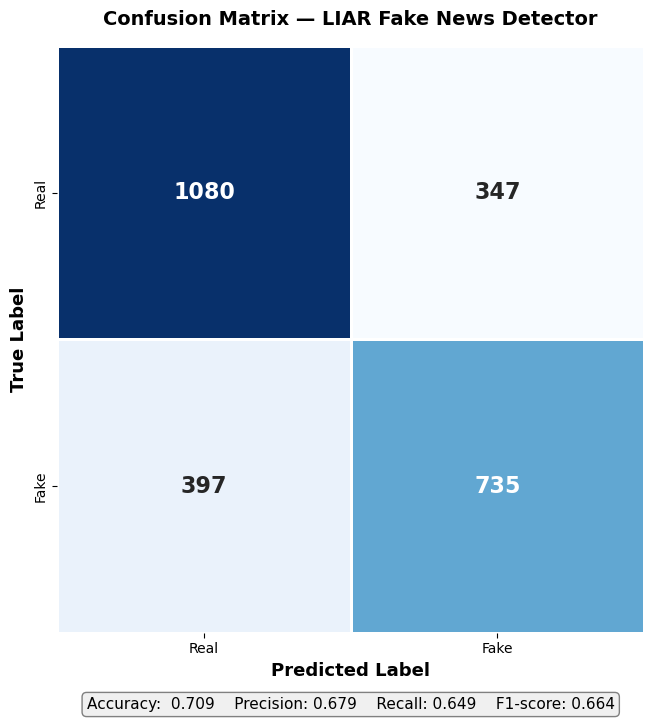

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import numpy as np

cm = confusion_matrix(y_test, y_pred)
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'],
            cbar=False, square=True, linewidths=2, linecolor='white',
            annot_kws={'size': 16, 'weight': 'bold'}, ax=ax)

ax.set_xlabel('Predicted Label', fontsize=13, fontweight='bold')
ax.set_ylabel('True Label', fontsize=13, fontweight='bold')
ax.set_title('Confusion Matrix — LIAR Fake News Detector',
             fontsize=14, fontweight='bold', pad=15)

metrics_text = (
    f"Accuracy:  {acc:.3f}    "
    f"Precision: {prec:.3f}    "
    f"Recall: {rec:.3f}    "
    f"F1-score: {f1:.3f}"
)
plt.figtext(0.5, -0.02, metrics_text, ha='center', fontsize=11,
            bbox=dict(boxstyle='round', facecolor='#f0f0f0', edgecolor='gray'))

plt.tight_layout()
plt.savefig('confusion_matrix_full.png', dpi=300, bbox_inches='tight')
plt.show()